In [5]:
#Importing the required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Step 1: Read csv file

In [6]:
# Load dataset
df = pd.read_csv("NVIDIA.csv")

In [7]:
# View first few rows
print(df.head())

         Date   Price    Open    High     Low     Vol. Change %
0  03/27/2026  167.52  170.00  170.97  167.01  196.21M   -2.17%
1  03/26/2026  171.24  176.07  176.51  171.14  186.15M   -4.16%
2  03/25/2026  178.68  177.10  181.22  176.85  162.60M    1.99%
3  03/24/2026  175.20  174.83  176.22  173.98  147.67M   -0.25%
4  03/23/2026  175.64  177.26  178.37  174.76  182.84M    1.70%


In [8]:
# Check structure and datatypes
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1276 entries, 0 to 1275
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      1276 non-null   object 
 1   Price     1276 non-null   float64
 2   Open      1276 non-null   float64
 3   High      1276 non-null   float64
 4   Low       1276 non-null   float64
 5   Vol.      1276 non-null   object 
 6   Change %  1276 non-null   object 
dtypes: float64(4), object(3)
memory usage: 69.9+ KB
None


In [9]:
# Statistical summary
print(df.describe())

             Price         Open         High          Low
count  1276.000000  1276.000000  1276.000000  1276.000000
mean     74.214976    74.249773    75.470878    72.874279
std      61.208062    61.319534    62.126892    60.304317
min      11.230000    10.970000    11.730000    10.810000
25%      20.655000    20.557500    20.867500    20.270000
50%      44.825000    44.775000    45.620000    44.080000
75%     128.455000   128.410000   130.632500   125.212500
max     207.040000   208.080000   212.190000   205.560000


Step 2: Data Cleaning

In [11]:
# Converting Date column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

In [12]:
# Sort data by date
df = df.sort_values(by='Date')

In [13]:
# Check for missing values
print(df.isnull().sum())

Date        0
Price       0
Open        0
High        0
Low         0
Vol.        0
Change %    0
dtype: int64


In [14]:
# Drop missing values (if any)
df = df.dropna()

In [15]:
# Remove duplicate rows
df = df.drop_duplicates()


In [37]:
df.reset_index(inplace=True)


In [38]:
# Set Date as index
df.set_index('Date', inplace=True)

In [ ]:
df.rename(columns={'Vol.': 'Volume'}, inplace=True) # Renaming the volume column

df['Volume'] = df['Volume'].apply(lambda x:  #lambda here is an inline function
    float(x.replace('M','')) * 1e6 if 'M' in x else # le6 = 1 * 10^6 for million
    float(x.replace('B','')) * 1e9  #le9 = 1 * 10^9 for billion
)

'''Handling the Million and Billion  data
Eg. 1.2M will be converted to 1.2 * 10^6
Eg. 0.5B will be converted to 0.5 * 10^9'''

In [ ]:
# Handling the percentage change data
df['Change %'] = df['Change %'].str.replace('%', '').astype(float)

STEP 3: Feature Engineering

In [40]:
# 3.1 Daily Percentage Return
df['Daily Return'] = df['Price'].pct_change()

In [ ]:
# 3.2 Moving Averages
df['MA50'] = df['Price'].rolling(window=50).mean()
df['MA200'] = df['Price'].rolling(window=200).mean()

'''rolling(window=50).mean() is used to take the 50 days price and calculate
the average and move forward by i day and repeat
To get the Moving Average of 50 (MA50) and 200 (MA200)'''

In [ ]:
# 3.3 Volatility
df['Volatility'] = df['Daily Return'].rolling(window=30).std()

'''rolling function is here too used to get the the 30 days return and get the 
standard deviations to get the volatility of the stock'''

In [ ]:
# 3.4 Price Range
df['Price Range'] = df['High'] - df['Low']

#Calculating range by subtracting the low price from the high price for each day to get the daily price range.

Step 4: Exploratory Data Analysis

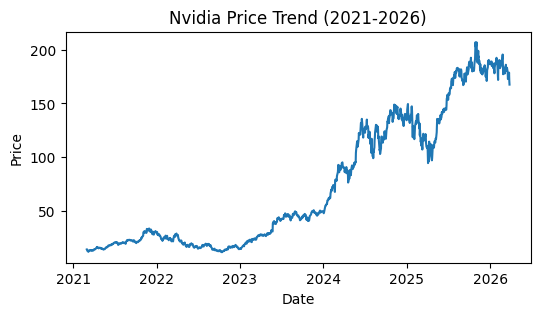

In [71]:
# 4.1 Price Trend
plt.figure(figsize=(6,3))
plt.plot(df['Price'])
plt.title("Nvidia Price Trend (2021-2026)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

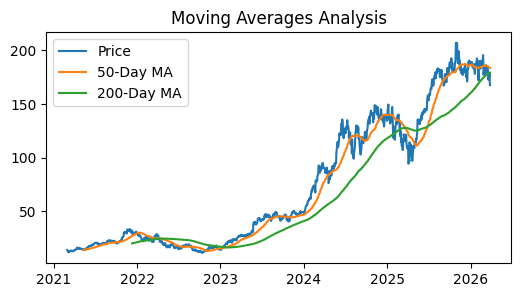

In [47]:
# 4.2 Moving Averages Analysis
plt.figure(figsize=(6,3))
plt.plot(df['Price'], label='Price')
plt.plot(df['MA50'], label='50-Day MA')
plt.plot(df['MA200'], label='200-Day MA')
plt.legend()
plt.title("Moving Averages Analysis")
plt.show()

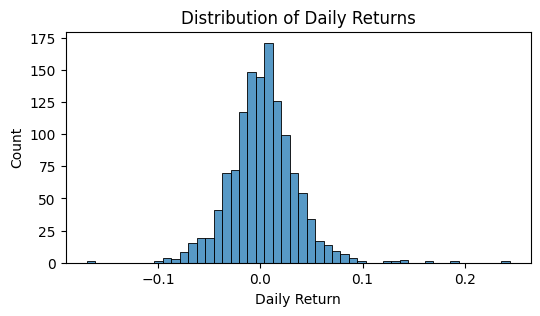

In [49]:
# 4.3 Daily Returns Distribution
plt.figure(figsize=(6,3))
sns.histplot(df['Daily Return'], bins=50)
plt.title("Distribution of Daily Returns")
plt.show()

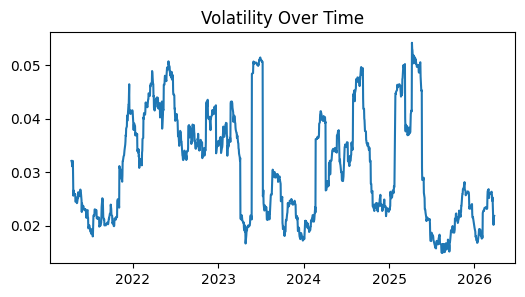

In [50]:
# 4.4 Volatility Trend
plt.figure(figsize=(6,3))
plt.plot(df['Volatility'])
plt.title("Volatility Over Time")
plt.show()

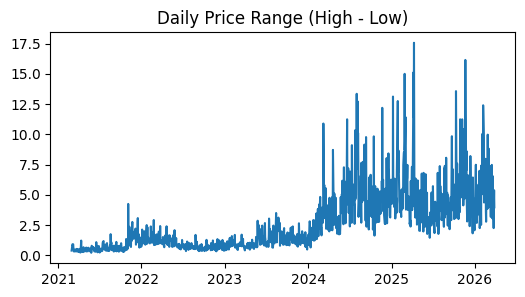

In [51]:
# 4.5 Price Range Analysis
plt.figure(figsize=(6,3))
plt.plot(df['Price Range'])
plt.title("Daily Price Range (High - Low)")
plt.show()

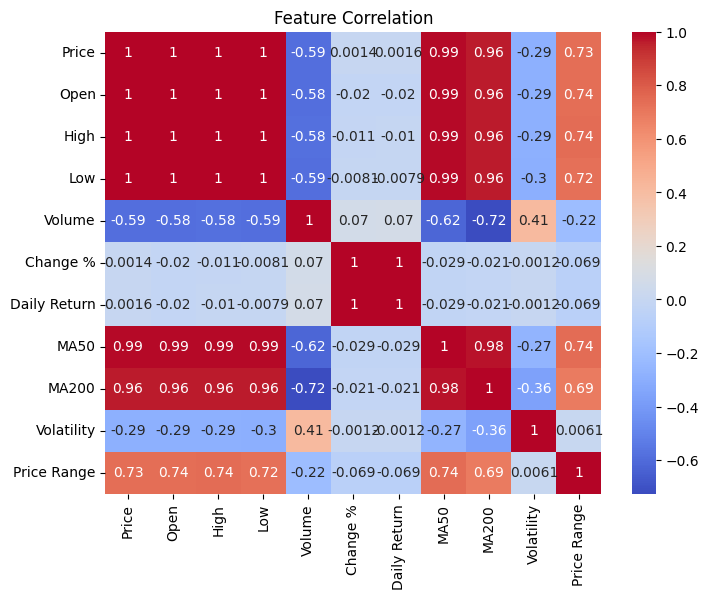

In [63]:
# 4.6 Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

C:\Users\Dakshesh\AppData\Local\Temp\ipykernel_13820\679127329.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df['Price'].resample('M').mean()


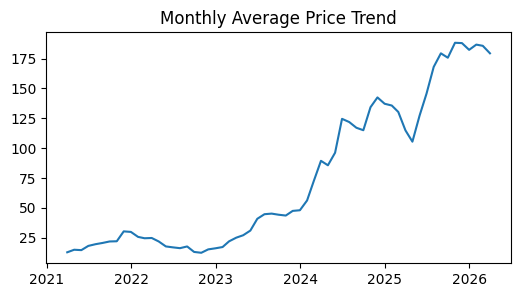

In [65]:
# Resample to monthly average closing price
monthly = df['Price'].resample('M').mean()

plt.figure(figsize=(6,3))
plt.plot(monthly)
plt.title("Monthly Average Price Trend")
plt.show()


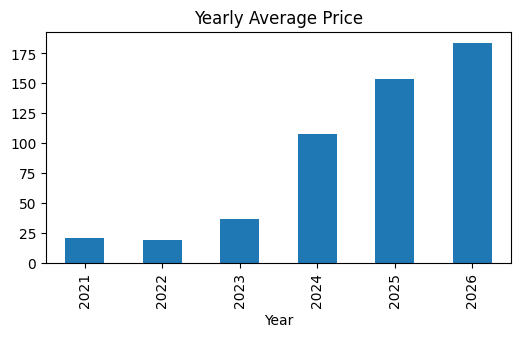

In [70]:
df['Year'] = df.index.year

yearly = df.groupby('Year')['Price'].mean()

yearly.plot(kind='bar', figsize=(6,3))
plt.title("Yearly Average Price")
plt.show()


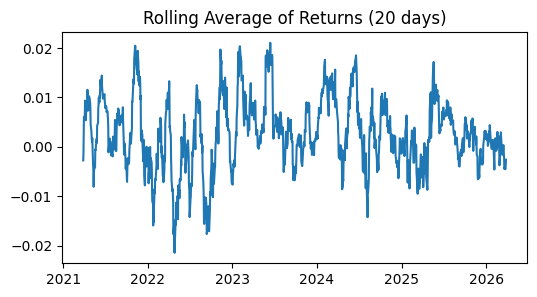

In [69]:
df['Return MA20'] = df['Daily Return'].rolling(20).mean()
plt.figure(figsize=(6,3))
plt.plot(df['Return MA20'])
plt.title("Rolling Average of Returns (20 days)")
plt.show()


Conclusion:

The analysis of Nvidia stock from 2021 to 2026 shows a strong overall upward trend with rapid growth in recent years, driven by increasing demand in AI and computing. While the stock offers high return potential, it also exhibits noticeable volatility and short-term fluctuations, indicating a high risk–high reward nature. Overall, Nvidia appears suitable for long-term investment, with opportunities for short-term gains during volatile periods.

------------------------------------------------------------------------------------------------------------------------------------------------------------

Insights:

1. Closing Price Trend

The stock price shows a consistent upward movement over the years, indicating strong growth and increasing investor confidence. The sharper rise in recent years suggests accelerated demand and positive market sentiment. This reflects the company’s strong performance and future growth expectations.

2. Moving Averages Analysis

The 50-day moving average staying above the 200-day moving average indicates a strong bullish trend. This crossover suggests sustained upward momentum and is often used as a signal for long-term growth. It confirms that the stock is performing well over extended periods.

3. Daily Returns Distribution

Daily returns are mostly clustered around zero, meaning small price changes occur frequently. However, the presence of extreme values shows occasional sharp price movements. This indicates that while the stock is generally stable, it can experience sudden gains or losses.

4. Volatility Trend

Volatility varies over time and appears in clusters rather than being constant. Periods of high volatility indicate increased uncertainty or major market events. This suggests that the stock goes through phases of stability followed by rapid fluctuations.

5. Price Range (High - Low)

The difference between daily high and low prices changes significantly across time. Larger price ranges indicate higher intraday activity and stronger buying or selling pressure. This reflects periods of intense trading and market participation.

6. Correlation Heatmap

Price-related features like Open, High, Low, and Close are highly correlated, meaning they move together consistently. This is expected as they represent different aspects of the same trading day. In contrast, returns and volatility behave more independently, showing different patterns.

7. Monthly Trend Analysis

Monthly average prices show a steady upward progression with minor fluctuations. This smooth trend highlights long-term growth while reducing short-term noise. It confirms that the stock maintains consistent performance over time.

8. Yearly Performance

Yearly averages clearly show that the stock price has increased significantly over time. Each successive year tends to have a higher average than the previous one. This indicates strong long-term growth and increasing market value.

9. Rolling Average of Returns

The rolling average of returns shows periods where returns remain consistently positive or negative. This indicates short-term trend persistence rather than completely random movement. It helps identify phases of stable growth or decline.

------------------------------------------------------------------------------------------------------------------------------------------------------------

Decision:

1. Long-Term Investment Strategy

Since the stock shows a strong upward trend and consistent yearly growth, it is suitable for long-term investment (Buy & Hold strategy). Investors can benefit from sustained growth over time.

2. Entry Point Strategy

Based on moving averages and correction phases, investors should enter during price dips or corrections rather than at peak levels. This reduces risk and improves potential returns.

3. Short-Term Trading Opportunity

Due to high volatility and frequent price swings, traders can capitalize on short-term price movements using swing trading strategies.

4. Risk Management Strategy

Since the stock shows high volatility and extreme daily returns, investors should use stop-loss and risk control measures to avoid major losses during sudden market drops.

5. Momentum-Based Strategy

The presence of trend persistence suggests that investors can follow momentum (buy during upward trends) instead of predicting reversals.

6. Avoid High Volatility Periods (for conservative investors)

Risk-averse investors should avoid entering during highly volatile phases, as these periods involve unpredictable price movements.

7. Volume-Based Confirmation

When price increases are supported by high trading volume, it indicates strong trends. Investors should confirm trends using volume before making decisions.

8. Diversification Strategy

Since the stock shows high risk–reward behavior, investors should diversify their portfolio instead of relying entirely on this stock.